## 🔍 1. Análise e Pré-processamento dos Dados

### 🗂️ 1.1 Preparação do Ambiente
- Criar um notebook (`.ipynb`) no **Jupyter** ou **Google Colab**  
- Importar bibliotecas essenciais (pandas, numpy, matplotlib, seaborn, etc.)


In [78]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn - Preprocessing
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Scikit-learn - Model Selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_predict,
    RandomizedSearchCV,
    GridSearchCV
)

# Scikit-learn - Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    classification_report
)

# Scikit-learn - Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Scipy
from scipy.stats import randint, uniform


### 📥 1.2 Importação e Visualização Inicial
- Carregar o conjunto de dados com `pd.read_csv()`
- Exibir as primeiras linhas para entender:
  - Estrutura
  - Tipos de dados
  - Colunas presentes

In [79]:
df = pd.read_csv('crop_yield.csv')

display(df.head())

df.info()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


### 📊 1.3 Estatística Descritiva
- Calcular média, mediana, desvio padrão e quartis  

In [80]:
for item in df['Crop'].unique():
    print(item)
    df_temp = df[df['Crop'] == item]
    df_temp = df_temp.drop(columns='Crop')
    display(df_temp.describe())

Cocoa, beans


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,39.000000,39.000000,39.000000,39.000000,39.000000
mean,2486.498974,18.203077,84.737692,26.183590,8883.128205
std,292.300450,0.296809,1.006009,0.263613,1745.030586
min,1934.620000,17.540000,82.110000,25.560000,5765.000000
25%,2305.750000,18.060000,84.175000,26.025000,7729.000000
50%,2424.550000,18.270000,84.850000,26.130000,8848.000000
75%,2705.210000,18.390000,85.495000,26.290000,9918.000000
max,3085.790000,18.700000,86.100000,26.810000,13056.000000


Oil palm fruit


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,39.000000,39.000000,39.000000,39.000000,39.000000
mean,2486.498974,18.203077,84.737692,26.183590,175804.692308
std,292.300450,0.296809,1.006009,0.263613,14919.869752
min,1934.620000,17.540000,82.110000,25.560000,142425.000000
25%,2305.750000,18.060000,84.175000,26.025000,166017.500000
50%,2424.550000,18.270000,84.850000,26.130000,175629.000000
75%,2705.210000,18.390000,85.495000,26.290000,185230.000000
max,3085.790000,18.700000,86.100000,26.810000,203399.000000


Rice, paddy


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,39.000000,39.000000,39.000000,39.000000,39.000000
mean,2486.498974,18.203077,84.737692,26.183590,32099.666667
std,292.300450,0.296809,1.006009,0.263613,4789.948436
min,1934.620000,17.540000,82.110000,25.560000,24686.000000
25%,2305.750000,18.060000,84.175000,26.025000,28293.500000
50%,2424.550000,18.270000,84.850000,26.130000,31101.000000
75%,2705.210000,18.390000,85.495000,26.290000,36098.500000
max,3085.790000,18.700000,86.100000,26.810000,42550.000000


Rubber, natural


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,39.000000,39.000000,39.000000,39.000000,39.000000
mean,2486.498974,18.203077,84.737692,26.183590,7824.897436
std,292.300450,0.296809,1.006009,0.263613,1600.255042
min,1934.620000,17.540000,82.110000,25.560000,5249.000000
25%,2305.750000,18.060000,84.175000,26.025000,6398.000000
50%,2424.550000,18.270000,84.850000,26.130000,7817.000000
75%,2705.210000,18.390000,85.495000,26.290000,9272.500000
max,3085.790000,18.700000,86.100000,26.810000,10285.000000


### 📈 1.4 Distribuições e Outliers
- Criar **histogramas** para visualizar a distribuição de cada variável  
- Gerar **boxplots** para identificar dispersão e possíveis outliers


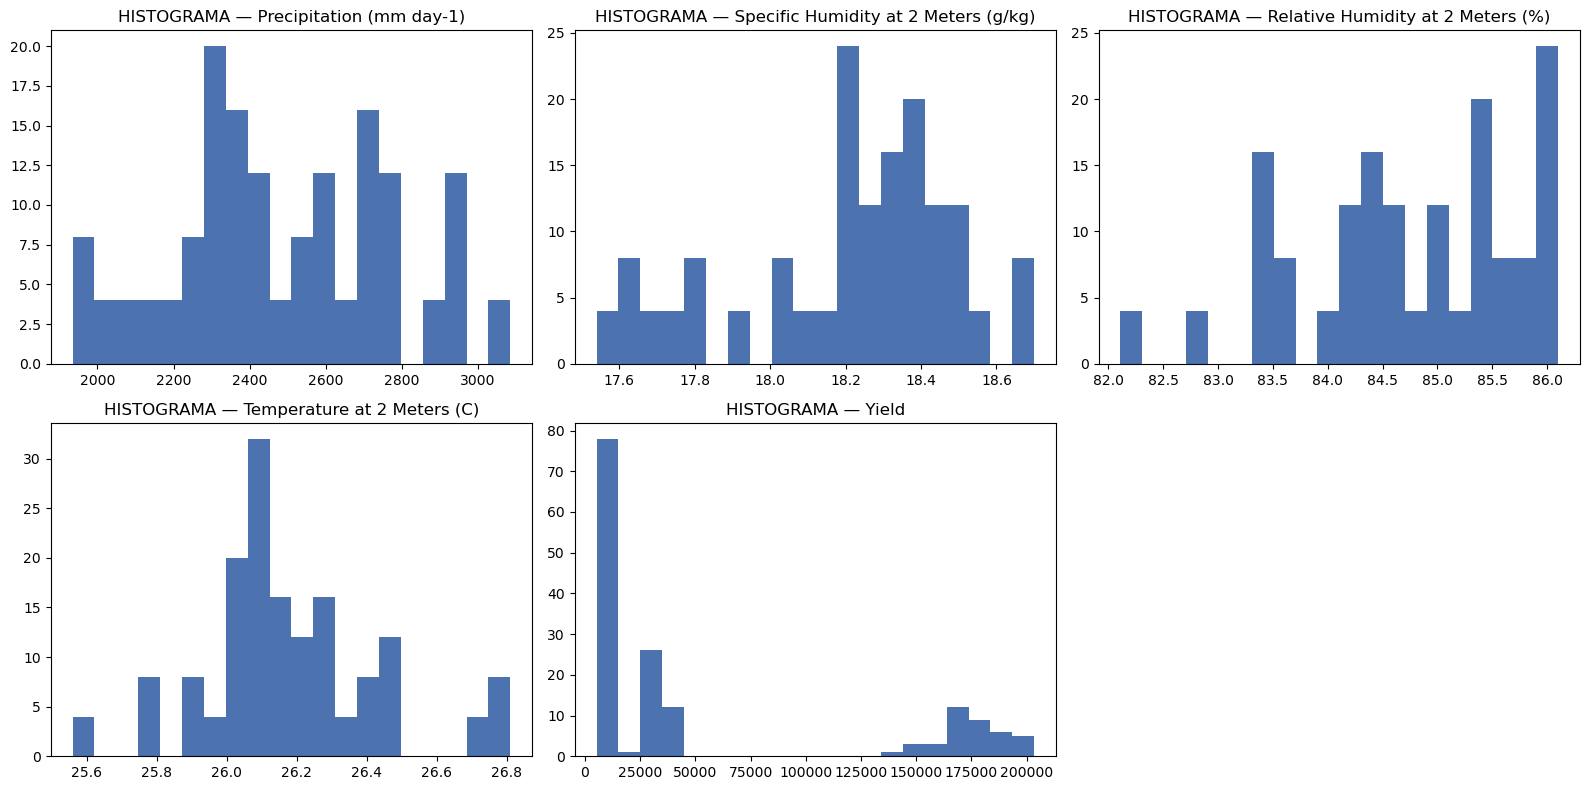

In [81]:
# ANALISE GERAL

#HISTOGRAMA
k = min(7, len(num_cols))
fig, axes = plt.subplots(nrows=(k+2)//3, ncols=3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols[:k]):
    axes[i].hist(df[col].dropna(), bins=20, color="#4C72B0")
    axes[i].set_title(f"HISTOGRAMA — {col}")
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout(); plt.show()

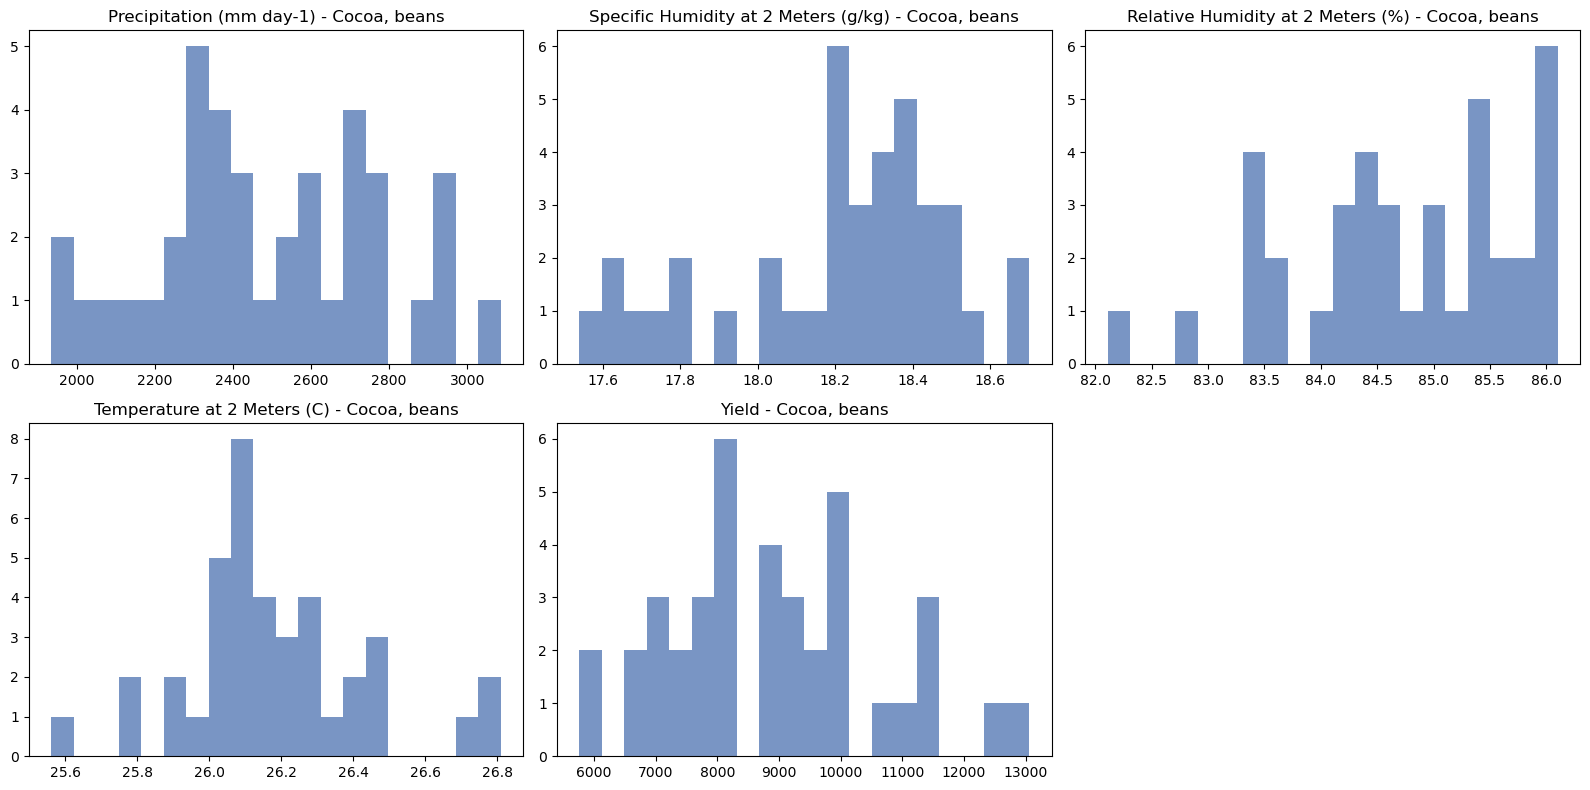

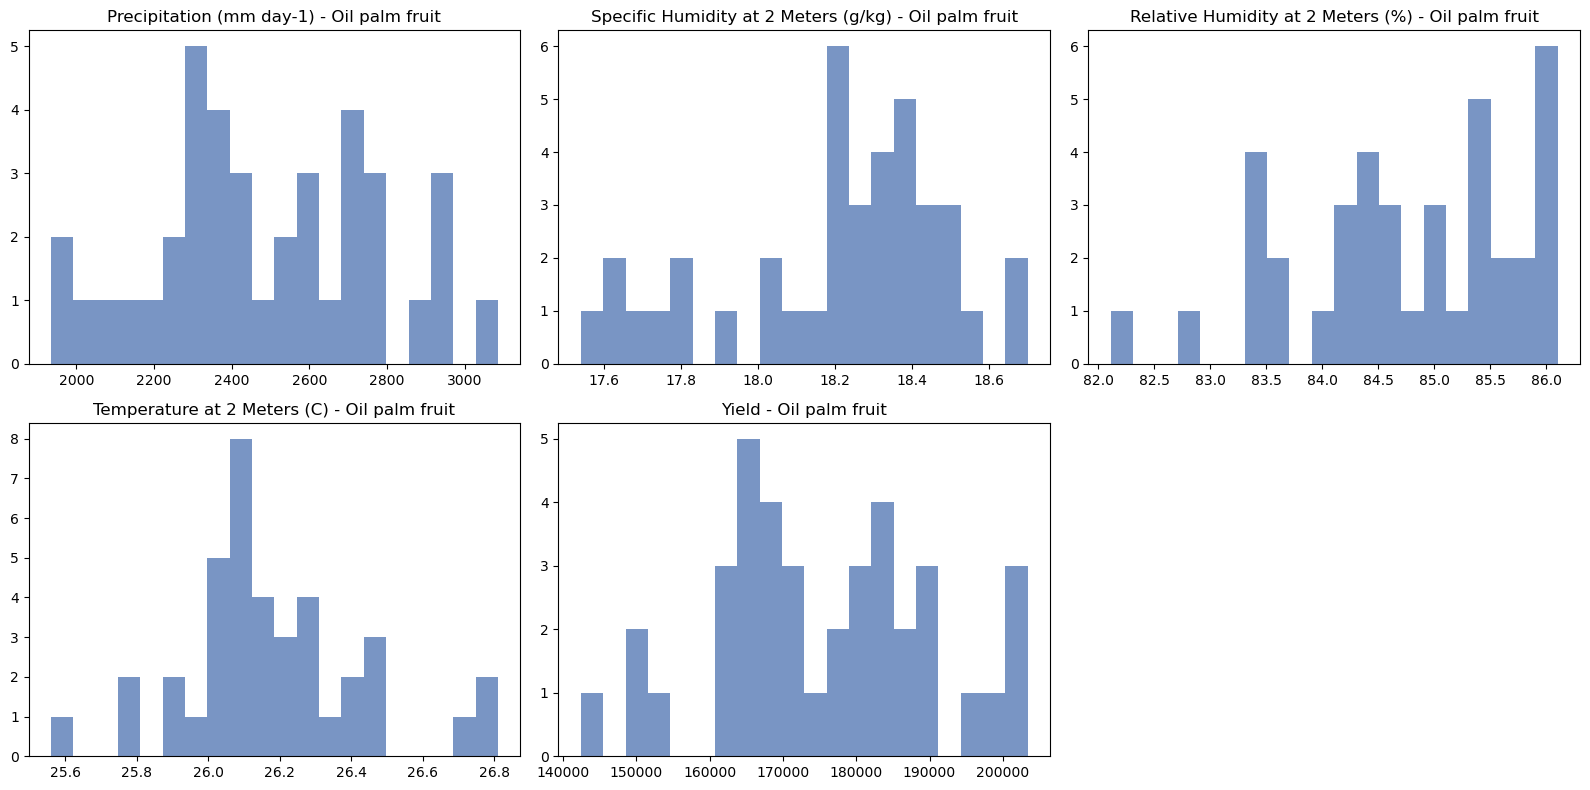

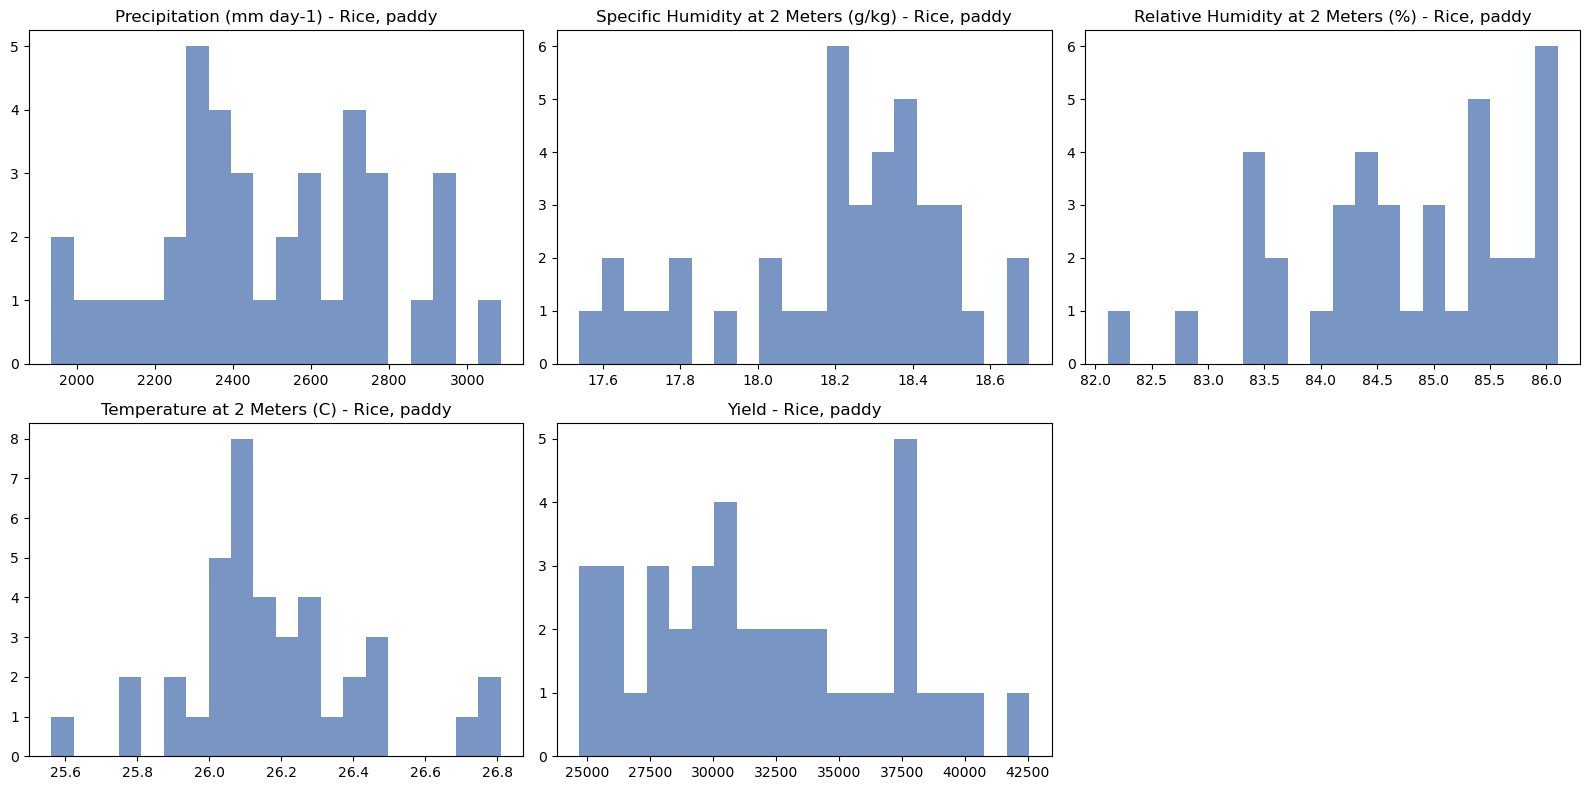

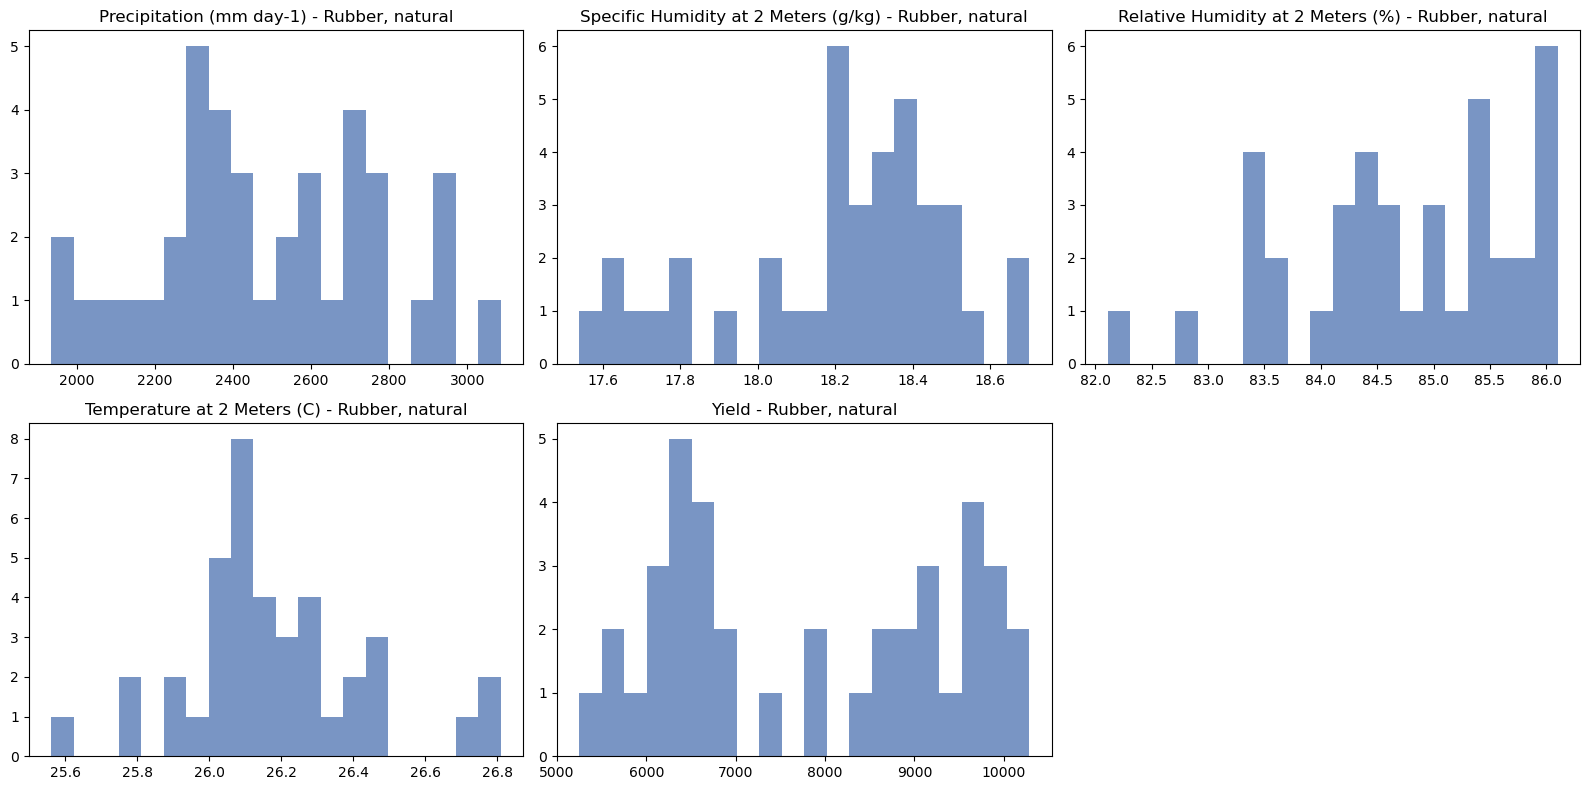

In [82]:
# HISTOGRAMAS POR CULTURA 

num_cols = [c for c in df.columns if c != 'Crop']
graos = df['Crop'].unique()

for g in graos:
    df_g = df[df['Crop'] == g]

    # criar grid de histogramas
    k = len(num_cols)
    fig, axes = plt.subplots(nrows=(k+2)//3, ncols=3, figsize=(16, 8))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        axes[i].hist(df_g[col].dropna(), bins=20, alpha=0.75, color="#4C72B0")
        axes[i].set_title(f"{col} - {g}")

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

C:\Users\arthu\AppData\Local\Temp\ipykernel_25196\620173682.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\arthu\AppData\Local\Temp\ipykernel_25196\620173682.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\arthu\AppData\Local\Temp\ipykernel_25196\620173682.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\arthu\AppData\Local\Temp\ipykernel_25196\620173682.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

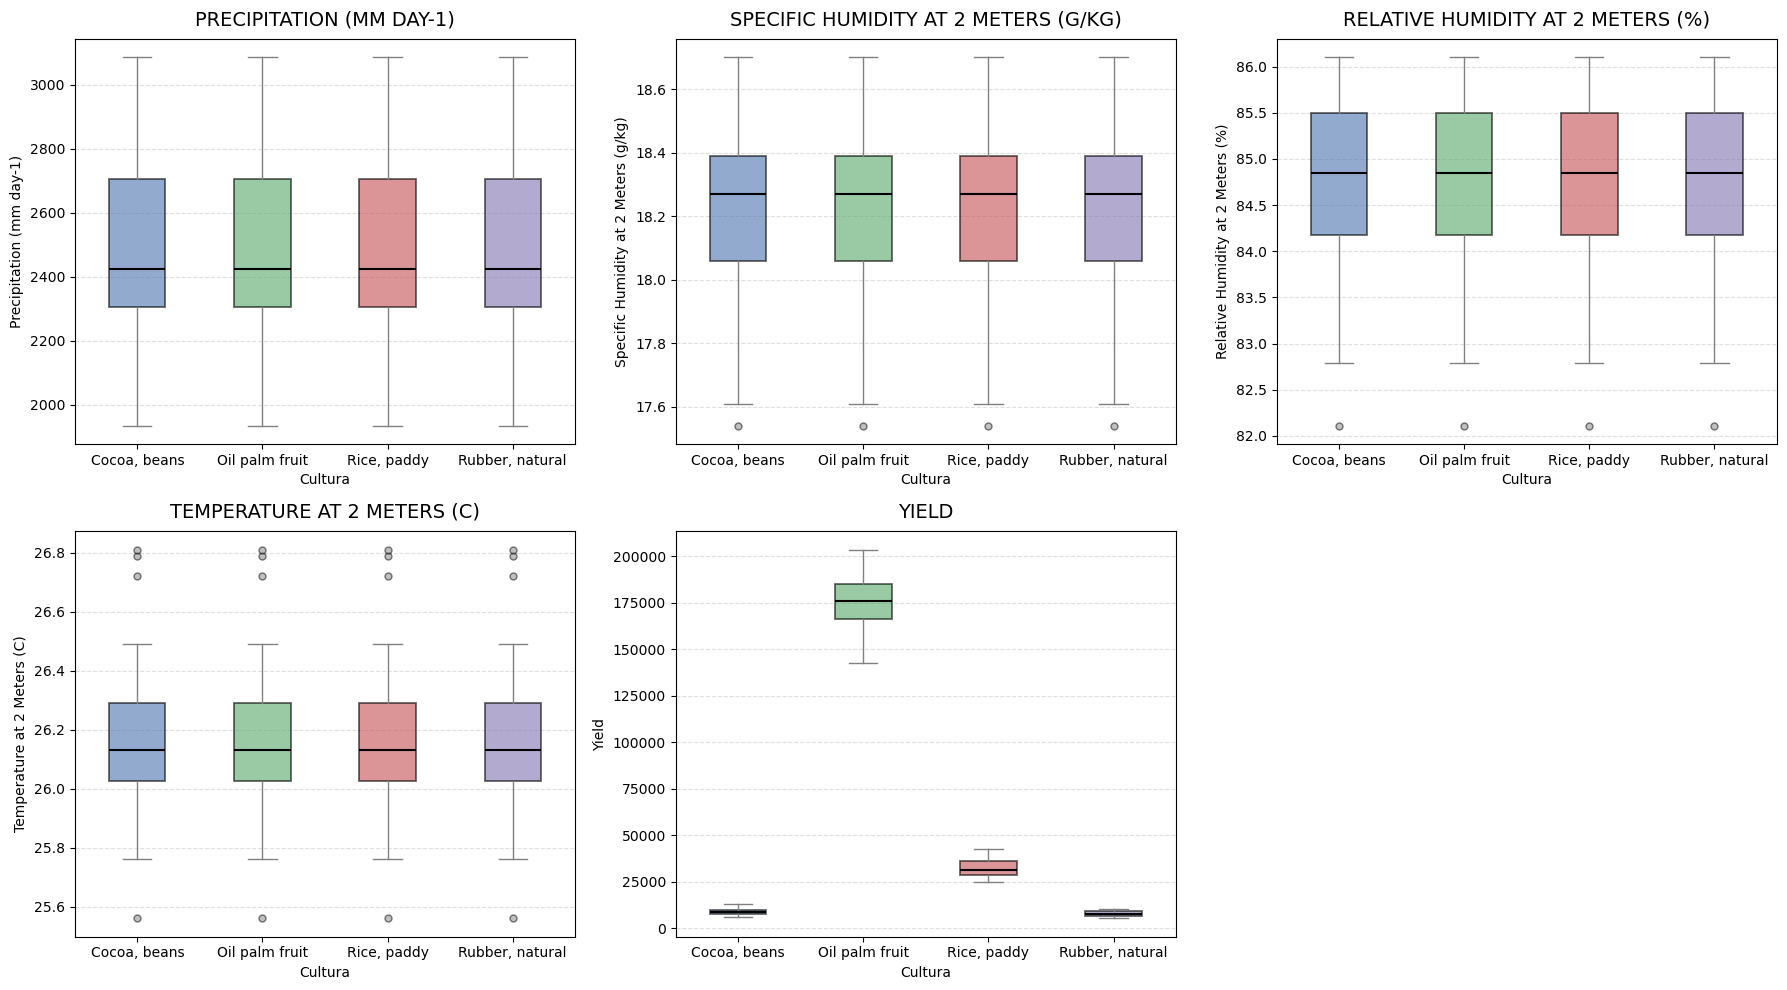

In [83]:
#BOXPLOT

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']
graos = df['Crop'].unique()

k = len(num_cols)                      
ncols = 3                               
nrows = (k + ncols - 1) // ncols        

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    
    ax = axes[i]
    data = [df[df['Crop'] == g][col] for g in graos]

    bp = ax.boxplot(
        data,
        labels=graos,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color='gray'),
        capprops=dict(color='gray'),
        boxprops=dict(linewidth=1.3),
        flierprops=dict(marker='o', markersize=5, markerfacecolor='gray', alpha=0.5)
    )

    for patch, color in zip(bp['boxes'], colors[:len(graos)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_title(f"{col.upper()}", fontsize=14, pad=10)
    ax.set_xlabel("Cultura", fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



### 🔗 1.5 Relação Entre Variáveis
- Criar **scatterplots** para analisar relações entre pares de features  
- Utilizar **heatmap de correlação** para avaliar força e direção das relações

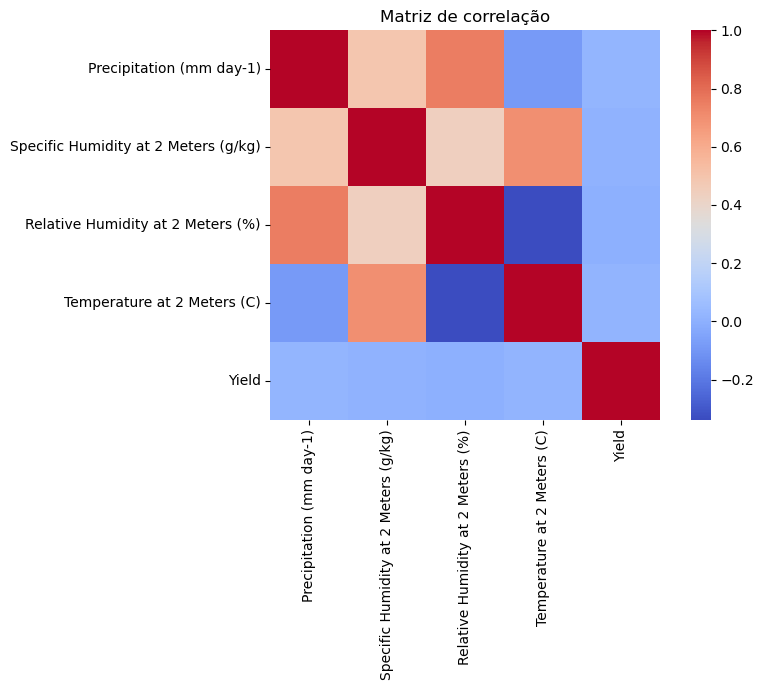

In [84]:
# HEATMAP DE CORRELAÇÃO

plt.figure(figsize=(9,7))
corr = df[num_cols].corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', square=True)
plt.title("Matriz de correlação"); plt.tight_layout(); plt.show()

## 🌾 2. Estimativa de rendimento

### 📏 Divisão dos Dados
- Separação do conjunto em **treino (70%)** e **teste (30%)**  

### 🤖 Implementação modelo
- Aplicação de modelo de regressão linear múltipla

### 🧪 Avaliação dos Modelos
Medir o desempenho no conjunto de teste utilizando:

- ✔️ Erro absoluto médio (MAE): média das diferenças absolutos entre os valores previstos para o modelo e os valores reais, ele é calculado somando as diferenças absolutas ebntre cada valor previsto (y) e o valor real correspondente (y^) e, em seguida, é dividido pelo npumero total de observações (n). 
- ✔️ Erro quadrático médio (MSE): média dos quadrados das diferenças entre os valores previstos e os reais. Dando mais peso a erros maiores devido à elevação ao quadrado.
- ✔️ Raiz quadrada do erro quadrático médio (RMSE): trata-se da raiz quadrada do MSE, trazendo o erro médio de volta para as mesmas unidades da variável alvo, tornando a métrica mais interpretável.
- ✔️ R² Score (Coeficiente de determinação): mede a proporção da variaboilidade dos dados, sendo que 1 indica que o modelo explica perfeitamente a variabilidade dos dados, enquanto 0 indica que ele não explica nenhuma variabilidade em relação à média.


In [97]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}


results = []

df = df.drop_duplicates()
x = pd.get_dummies(df.drop('Yield', axis=1), drop_first=True)
y = df['Yield']

# Split 70/30 
X_train, X_test, y_train, y_test = train_test_split(
        x, y, test_size=0.30, random_state=42)

# Padronização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


for name, model in models.items():
    
    # Treinar modelo
    model.fit(X_train, y_train)
    
    # Previsão
    y_pred = model.predict(X_test)
    
    # Métricas
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Validação Cruzada (5 folds)
    cv_scores = cross_val_score(model, X_train, y_train, 
                                scoring='r2', cv=5)
    
    results.append({
        "Modelo": name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2),
        "R² Teste": round(r2,2),
        "R² CV Médio": round(cv_scores.mean(),2)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R² Teste", ascending=False)

results_df

,Modelo,RMSE,MAE,R² Teste,R² CV Médio
0,Linear Regression,7963.84,4543.06,0.99,0.99
1,Random Forest,8508.25,4143.33,0.98,0.99
2,Gradient Boosting,8524.83,4617.79,0.98,0.99
3,SVR,71559.75,42962.98,-0.13,-0.27
4,KNN,76380.35,63364.51,-0.29,-0.26


## 🌾 3. Análises de tendências de produtividade